In [1]:
import os
from pathlib import Path
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

abs_path = os.path.abspath(os.getcwd())
ROOT_DIRECTORY = os.path.abspath(os.path.join(abs_path, '..', ".."))
data_folder = os.path.join(ROOT_DIRECTORY, "data", "raw")

display(data_folder)
display(os.listdir(data_folder))

'/home/dibarra/Documents/egofets-project/data/raw'

['2026-06-26_test1.hdf5',
 '2026-06-29_test2.1.hdf5',
 '2026-06-29_test2.2.hdf5',
 '2026-06-29_test2.hdf5',
 '2026-06-30_test3.hdf5']

/ (ROOT)
 | Batch1_Dispositivo1_Output1_00/
    | curve_000/
       - calculated_V_DS/ (Shape: (92,), type: float64)
       - calculated_V_GS/ (Shape: (92,), type: float64)
       - measured_I_DS/ (Shape: (92,), type: float64)
       - measured_I_GS/ (Shape: (92,), type: float64)
       - measured_V_DS/ (Shape: (92,), type: float64)
       - measured_V_GS/ (Shape: (92,), type: float64)
       - time/ (Shape: (92,), type: float64)
    | curve_001/
       - calculated_V_DS/ (Shape: (92,), type: float64)
       - calculated_V_GS/ (Shape: (92,), type: float64)
       - measured_I_DS/ (Shape: (92,), type: float64)
       - measured_I_GS/ (Shape: (92,), type: float64)
       - measured_V_DS/ (Shape: (92,), type: float64)
       - measured_V_GS/ (Shape: (92,), type: float64)
       - time/ (Shape: (92,), type: float64)
    | curve_002/
       - calculated_V_DS/ (Shape: (92,), type: float64)
       - calculated_V_GS/ (Shape: (92,), type: float64)
       - measured_I_DS/ (Shape: (92,), type: fl

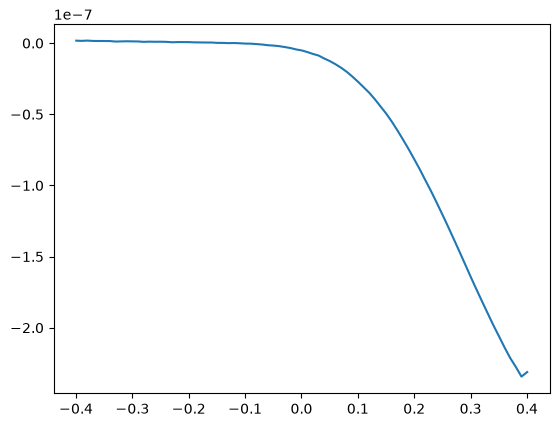

In [5]:
file_name = "2026-06-26_test1.hdf5"
file_path = os.path.join(data_folder, file_name)

# We're now creating a function to plot transfer curve: I_DS (A) vs V_GS (V)
# 2 pairs of dset (array) -> x, y data pd
def transfer_curve(x_data, y_data):
    fig, ax = plt.subplots()
    ax.plot(x_data, y_data)

    plt.show()

with h5py.File(file_path, 'r') as file:
    def tree_levels(name, item):
        level = name.count('/')
        sangria = '   ' * level
        short_name = name.split('/')[-1]

        if isinstance(item, h5py.Group):
            print(f'{sangria} | {short_name}/')
        else:
            print(f"{sangria} - {short_name}/ (Shape: {item.shape}, type: {item.dtype})")

    print("/ (ROOT)")
    content_files = file.visititems(tree_levels) # Create a tree-like files
    curve = file['Batch1_Dispositivo1_Transfer1_00']["curve_000"] # Acess to one measure
    curve_I_DS = curve["measured_I_DS"][:] # this is a data set and can be readed with "[:]", it's y_data
    curve_V_GS = curve["measured_V_GS"][:] # this it's x_data
    transfer_curve(curve_V_GS, curve_I_DS)